In [8]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [9]:
pre_SS_opto = ['AE_368','AE_369','AE_449']
pre_SS_control = ['AE_363','AE_435','AE_389']
post_SS_opto = ['AE_376','AE_415','AE_469']
post_SS_control = ['AE_391','AE_447','AE_488']

all_animals = np.concatenate([pre_SS_opto, pre_SS_control,post_SS_opto, post_SS_control])

In [10]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 3r.csv'))

In [11]:
df

,Unnamed: 0,animal,d',condition
0,0,AE_368,2.019125,pre expert opto
1,1,AE_369,1.796091,pre expert opto
2,2,AE_449,2.635457,pre expert opto
3,3,AE_363,2.158951,pre expert control
4,4,AE_435,1.724797,pre expert control
5,5,AE_389,1.785744,pre expert control
6,6,AE_376,-0.041087,post expert opto
7,7,AE_415,-0.072342,post expert opto
8,8,AE_469,0.762863,post expert opto
9,9,AE_391,2.011821,post expert control


In [12]:
opto_pre_dps = []
control_pre_dps = []

for row in df.iloc:
    if row['condition'] == 'pre expert opto':
        opto_pre_dps.append(row['d\''])
    if row['condition'] == 'pre expert control':
        control_pre_dps.append(row['d\''])

opto_post_dps = []
control_post_dps = []

for row in df.iloc:
    if row['condition'] == 'post expert opto':
        opto_post_dps.append(row['d\''])
    if row['condition'] == 'post expert control':
        control_post_dps.append(row['d\''])

Pre expert Opto vs control
Opto d' = 2.1502244360506784 +/- 0.35498732590042514
Control d' = 1.8898309733501308 +/- 0.1919166050113175
3 opto animals
3 control animals
ttest_ind
sig: False
pval: 0.7934464507801788

Post expert Opto vs control
Opto d' = 0.21647792867939633 +/- 0.3865634511308452
Control d' = 2.1836078595351283 +/- 0.24547214153920568
3 opto animals
3 control animals
ttest_ind
sig: True
pval: 0.0018545397763663663


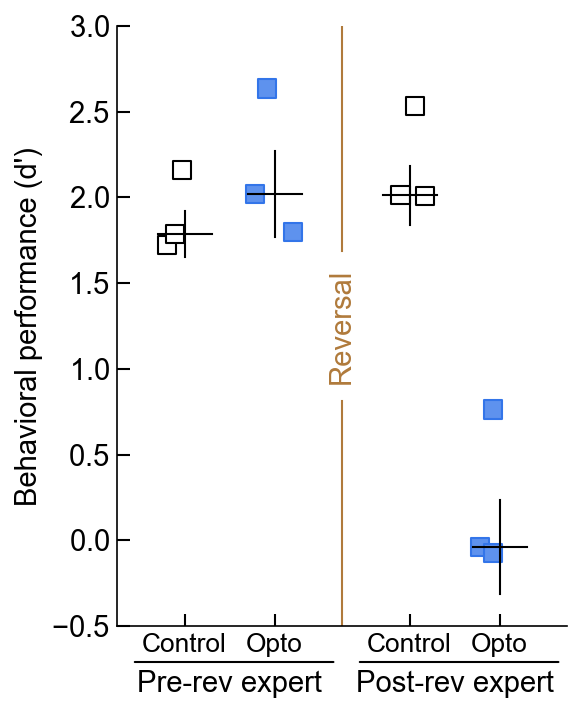

In [13]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(3, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0.25
meanwidth = 0.25

################################################################################################################
sz = 75

data = [control_pre_dps, opto_pre_dps, control_post_dps, opto_post_dps]  


# sz = 35
width = 0.3
switch_offset = 0.25

X = [np.ones(len(l))*idx + polarity*switch_offset for idx,(l,polarity) in enumerate(zip(data,[-1,-1,1,1]))]
_,Y = ilep.violin(np.concatenate(X),np.concatenate(data),width=0.75,minjitter=0.075)
X,_ = ilep.violin(np.concatenate(X),np.concatenate(data),width=0.75,minjitter=0.075)

e_colors = ['k']*len(control_pre_dps)
e_colors = np.concatenate([e_colors,[LASER_COLOR]*len(opto_pre_dps)])
e_colors = np.concatenate([e_colors,['k']*len(control_post_dps)])
e_colors = np.concatenate([e_colors,[LASER_COLOR]*len(opto_post_dps)])
f_colors = ['white']*len(control_pre_dps)
f_colors = np.concatenate([f_colors,[LIGHT_LASER]*len(opto_pre_dps)])
f_colors = np.concatenate([f_colors,['white']*len(control_post_dps)])
f_colors = np.concatenate([f_colors,[LIGHT_LASER]*len(opto_post_dps)])

ax.scatter(X,Y,fc=f_colors,ec=e_colors,s=sz,marker='s')
for idx,(column,polarity) in enumerate(zip(data,[-1,-1,1,1])):
    Y = ilep.rmnan(column)
    X = np.random.uniform(-width/2,width/2,size=len(Y)) + idx
    
    mean = np.mean(Y)
    SEM = sem(Y)

    ax.plot([idx+polarity*switch_offset- width,idx+polarity*switch_offset + width],[np.median(column)]*2,lw=1,color='k')
    data_sem = sem(Y)
    ax.plot([idx+polarity*switch_offset, idx+polarity*switch_offset],[np.median(column)-data_sem,np.median(column)+data_sem],lw=1,color='k')


################################################################################################################

labels = ['Control','Opto']

ax.set_ylim([-0.5,3])
ylab = ax.set_ylabel('Behavioral performance (d\')')

ax.set_xlim([-0.75-switch_offset,3.75+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2+switch_offset,3+switch_offset])
ax.set_xticklabels(['Control','Opto','Control','Opto'])

xtick_pos_pre = np.mean(ax.get_xticks()[:2])
xtick_pos_post = np.mean(ax.get_xticks()[2:4])
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac)
t1 = ax.text(xtick_pos_pre, Yval, 'Pre-rev expert', ha='center', va='bottom', fontsize=stdfont,color='k')
t2 = ax.text(xtick_pos_post, Yval, 'Post-rev expert', ha='center', va='bottom',  fontsize=stdfont,color='k')
ax.annotate('', xy=(0.03, -stdyfrac), xycoords='axes fraction', xytext=(0.49, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(0.53, -stdyfrac), xycoords='axes fraction', xytext=(0.99, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass
    
### Linear
Y = np.mean(ax.get_ylim())
X = np.mean(ax.get_xlim())
t = ax.text(X,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
ax.plot([X]*2,[ax.get_ylim()[0],Y-np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)
ax.plot([X]*2,[ax.get_ylim()[1],Y+np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)

print('Pre expert Opto vs control')
print(f"Opto d' = {np.nanmean(opto_pre_dps)} +/- {np.nanstd(opto_pre_dps)}")
print(f"Control d' = {np.nanmean(control_pre_dps)} +/- {np.nanstd(control_pre_dps)}")
print(f"{len(ilep.rmnan(opto_pre_dps))} opto animals")
print(f"{len(ilep.rmnan(control_pre_dps))} control animals")
print('ttest_ind')
test = ttest_ind(ilep.rmnan(opto_pre_dps),ilep.rmnan(control_pre_dps),alternative='less')
pval = test.pvalue
sig = np.abs(pval) < 0.05
print('sig: '+str(sig))
print('pval: '+str(pval) + '\n')

print('Post expert Opto vs control')
print(f"Opto d' = {np.nanmean(opto_post_dps)} +/- {np.nanstd(opto_post_dps)}")
print(f"Control d' = {np.nanmean(control_post_dps)} +/- {np.nanstd(control_post_dps)}")
print(f"{len(ilep.rmnan(opto_post_dps))} opto animals")
print(f"{len(ilep.rmnan(control_post_dps))} control animals")
print('ttest_ind')
test = ttest_ind(ilep.rmnan(opto_post_dps),ilep.rmnan(control_post_dps),alternative='less')
pval = test.pvalue
sig = np.abs(pval) < 0.05
print('sig: '+str(sig))
print('pval: '+str(pval))


artists = [ylab,t1,t2]

# fig.savefig(os.path.join('..','..','Figures','Figure 3r.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')